# Proyecto de Series Temporales - Sistema de Prediccion de Ventas

**Objetivo del proyecto:**

1. Comprender un dataset nuevo
2. Analizar la serie temporal y estudiar sus caracteristicas
3. Entrenar un modelo ARIMA para predecir las ventas a futuro
4. Predecir con el conjunto de test y medir el rendimiento
5. Guardar el modelo

**Contexto de negocio:** la empresa quiere abrir un almacen en otra localizacion y necesita
estimar el ritmo de ventas de los proximos meses para dimensionar el espacio.

## Carga del conjunto de datos

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [154]:
pd.set_option("display.max_columns", None)

In [155]:
#Carga del dataset desde la carpeta de datos en crudo
df = pd.read_csv("/Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-Time-Series/data/raw/sales.csv")

print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("")
print(df.dtypes)

df.head()

Filas: 366
Columnas: 2

date         str
sales    float64
dtype: object


,date,sales
0,2022-09-03 17:10:08.079328,55.292157
1,2022-09-04 17:10:08.079328,53.803211
2,2022-09-05 17:10:08.079328,58.141693
3,2022-09-06 17:10:08.079328,64.530899
4,2022-09-07 17:10:08.079328,66.013633


In [156]:
df.tail()

,date,sales
361,2023-08-30 17:10:08.079328,989.600354
362,2023-08-31 17:10:08.079328,994.987326
363,2023-09-01 17:10:08.079328,995.814415
364,2023-09-02 17:10:08.079328,997.350214
365,2023-09-03 17:10:08.079328,1000.482785


## Construir y Analizar la serie temporal


### Construccion de la estructura de datos valida

In [157]:
#Conversion de la columna a tipo fecha
df["date"] = pd.to_datetime(df["date"])

#Eliminacion de la parte horaria, que es identica en todas las filas y no aporta nada
df["date"] = df["date"].dt.normalize()

#La fecha pasa a ser el indice
df = df.set_index("date")

print(df.index.dtype)
df.head()

datetime64[us]


,sales
date,
2022-09-03,55.292157
2022-09-04,53.803211
2022-09-05,58.141693
2022-09-06,64.530899
2022-09-07,66.013633


In [158]:
#Revision de la regularidad de la serie antes de declarar la frecuencia
day_gaps = df.index.to_series().diff().dt.days.value_counts()

print("Separacion entre observaciones consecutivas (en dias):")
print(day_gaps)
print("")
print("Nulos:", df.isnull().sum().sum())
print("Fechas duplicadas:", df.index.duplicated().sum())

Separacion entre observaciones consecutivas (en dias):
date
1.0    365
Name: count, dtype: int64

Nulos: 0
Fechas duplicadas: 0


In [159]:
#Declaracion de la frecuencia diaria
df = df.asfreq("D")

#Comprobacion de que asfreq no ha introducido huecos
print("Nulos tras declarar la frecuencia:", df.isnull().sum().sum())
print("")
print("Fecha inicial:", df.index.min().date())
print("Fecha final:  ", df.index.max().date())
print("Observaciones:", len(df))

Nulos tras declarar la frecuencia: 0

Fecha inicial: 2022-09-03
Fecha final:   2023-09-03
Observaciones: 366


In [160]:
#La serie como objeto unico
sales_series = df["sales"]

sales_series.describe()

count     366.000000
mean      524.963968
std       275.089698
min        53.803211
25%       290.186822
50%       520.699468
75%       763.289263
max      1000.482785
Name: sales, dtype: float64

### Grafico de la serie

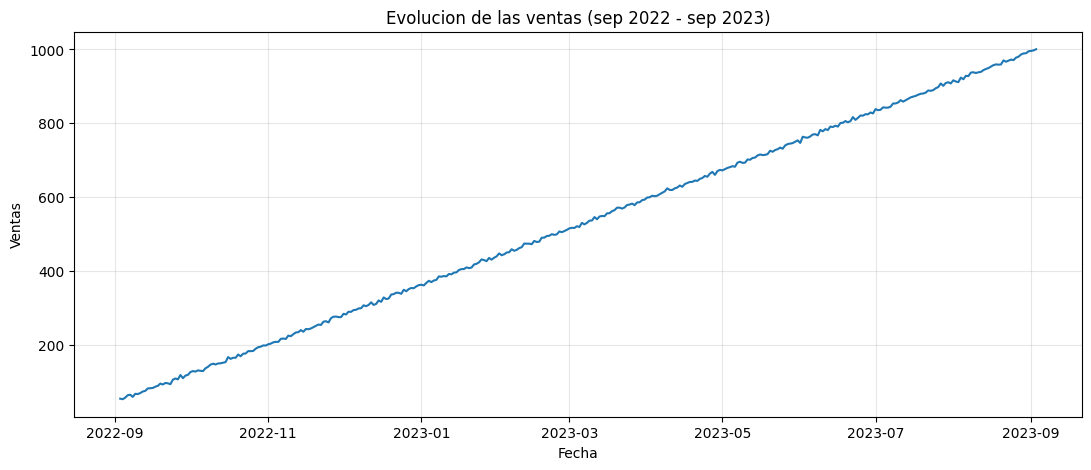

In [161]:
plt.figure(figsize = (13, 5))
plt.plot(sales_series.index, sales_series.values)
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Evolucion de las ventas (sep 2022 - sep 2023)")
plt.grid(alpha = 0.3)
plt.show()

### Tensor de la serie temporal

- Frecuencia: diaria (`D`)
- Periodo cubierto: del **3 de septiembre de 2022** al **3 de septiembre de 2023**
- Total: **366 observaciones**, exactamente un año completo


### Tendencia

La Tendencia es claramente **creciente**

In [162]:
#Comparacion de los extremos de la serie
print("Media de los primeros 30 dias:", round(sales_series[:30].mean(), 2))
print("Media de los ultimos 30 dias: ", round(sales_series[-30:].mean(), 2))
print("Crecimiento:", round(sales_series[-30:].mean() / sales_series[:30].mean(), 2), "veces")
print("")
print("Valor minimo:", round(sales_series.min(), 2))
print("Valor maximo:", round(sales_series.max(), 2))

Media de los primeros 30 dias: 89.07
Media de los ultimos 30 dias:  961.82
Crecimiento: 10.8 veces

Valor minimo: 53.8
Valor maximo: 1000.48


In [163]:
#Comprobacion de si el crecimiento es lineal: incremento diario medio por tramos
daily_change = sales_series.diff()

segment_rows = []
for start in range(0, 360, 60):
    segment = daily_change[start:start + 60]
    segment_rows.append([
        str(start) + " - " + str(start + 60),
        segment.mean(),
        segment.std()
    ])

segment_table = pd.DataFrame(segment_rows, columns = ["tramo (dias)", "incremento medio diario",
                                                      "desviacion"])
segment_table = segment_table.round(3)

segment_table

,tramo (dias),incremento medio diario,desviacion
0,0 - 60,2.495,4.310
1,60 - 120,2.667,4.461
2,120 - 180,2.558,3.979
3,180 - 240,2.636,4.075
4,240 - 300,2.587,4.824
5,300 - 360,2.615,4.208


**La tendencia es lineal y muy estable.** El incremento diario medio se mantiene entre
**2,50 y 2,67 unidades** en los seis tramos de dos meses, sin acelerarse ni frenarse.

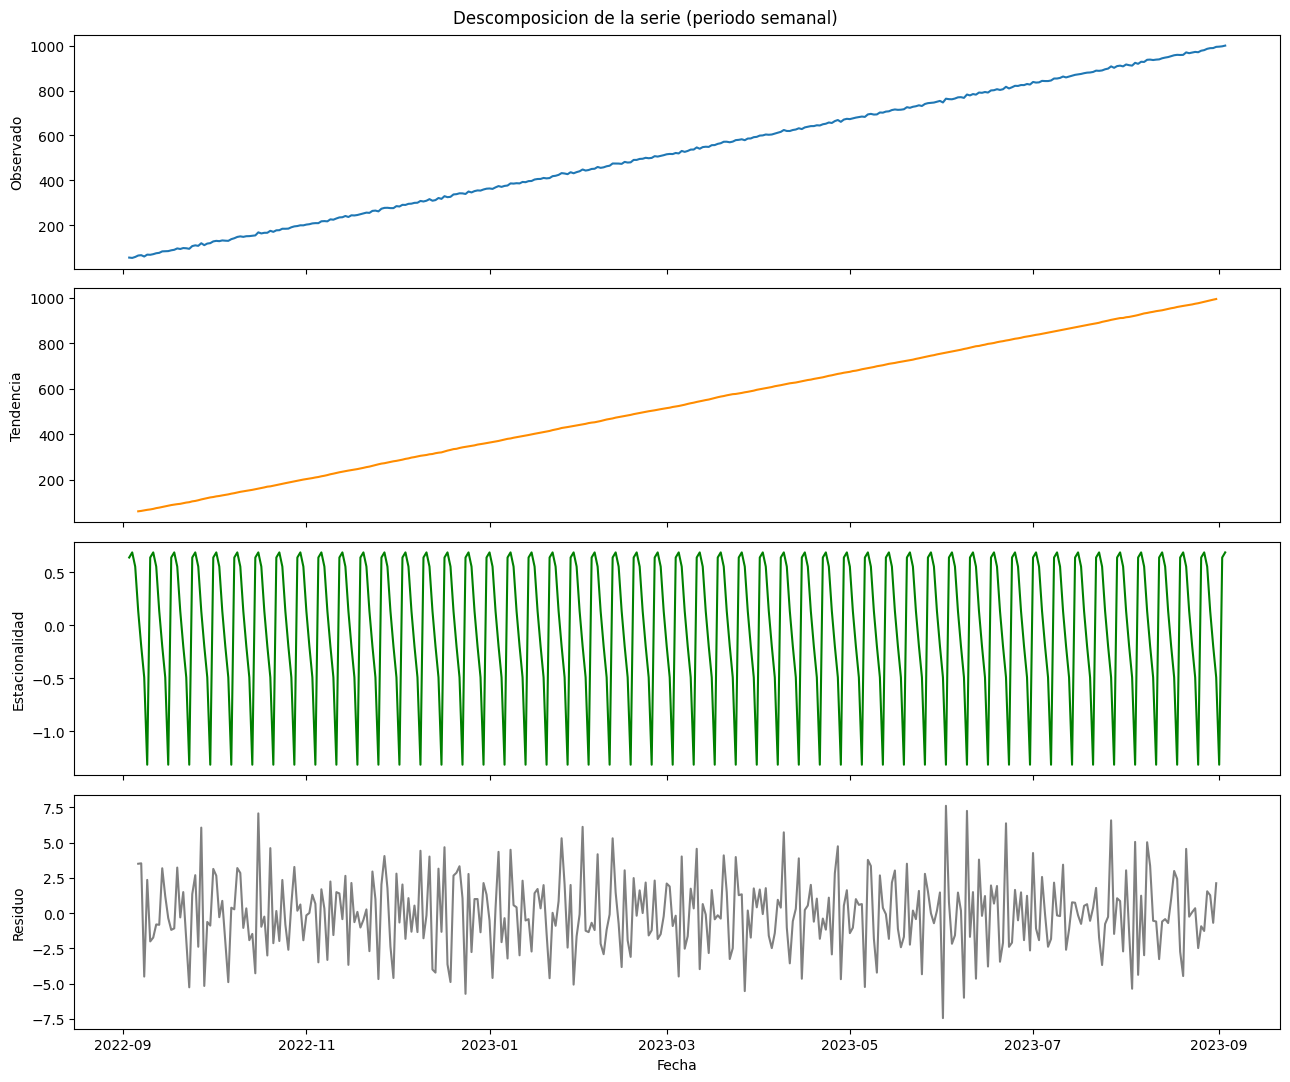

In [164]:
#Descomposicion de la serie en tendencia, estacionalidad y residuo
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(sales_series, model = "additive", period = 7)

fig, axis = plt.subplots(4, 1, figsize = (13, 11), sharex = True)

axis[0].plot(decomposition.observed)
axis[0].set_ylabel("Observado")
axis[1].plot(decomposition.trend, color = "darkorange")
axis[1].set_ylabel("Tendencia")
axis[2].plot(decomposition.seasonal, color = "green")
axis[2].set_ylabel("Estacionalidad")
axis[3].plot(decomposition.resid, color = "gray")
axis[3].set_ylabel("Residuo")
axis[3].set_xlabel("Fecha")

plt.suptitle("Descomposicion de la serie (periodo semanal)")
plt.tight_layout()
plt.show()

In [165]:
#Comparacion de magnitudes de cada componente
print("Desviacion de la serie completa:", round(sales_series.std(), 2))
print("Amplitud del componente estacional:",
      round(decomposition.seasonal.max() - decomposition.seasonal.min(), 4))
print("Desviacion del residuo:", round(decomposition.resid.std(), 4))

Desviacion de la serie completa: 275.09
Amplitud del componente estacional: 2.0017
Desviacion del residuo: 2.6105


**No hay estacionalidad relevante.** El componente estacional tiene una amplitud de
**2,00 unidades** frente a una desviacion total de la serie de **275,09**. Es decir, la
supuesta pauta semanal representa menos del **1%** de la variacion.

### Es Estacionaria?



from statsmodels.tsa.stattools import adfuller

def check_stationarity(series, name):
    result = adfuller(series.dropna())
    print("---", name)
    print("  Estadistico ADF:", round(result[0], 4))
    print("  p-valor:", round(result[1], 4))
    if result[1] < 0.05:
        print("  Conclusion: ES estacionaria (se rechaza la hipotesis nula)")
    else:
        print("  Conclusion: NO es estacionaria")
    print("")

check_stationarity(sales_series, "Serie original")
check_stationarity(sales_series.diff(), "Primera diferencia")
check_stationarity(sales_series.diff().diff(), "Segunda diferencia")

**La serie original NO es estacionaria:** p-valor de **0,9862**, muy por encima de 0,05,
asi que no se puede rechazar la hipotesis nula de que existe raiz unitaria.


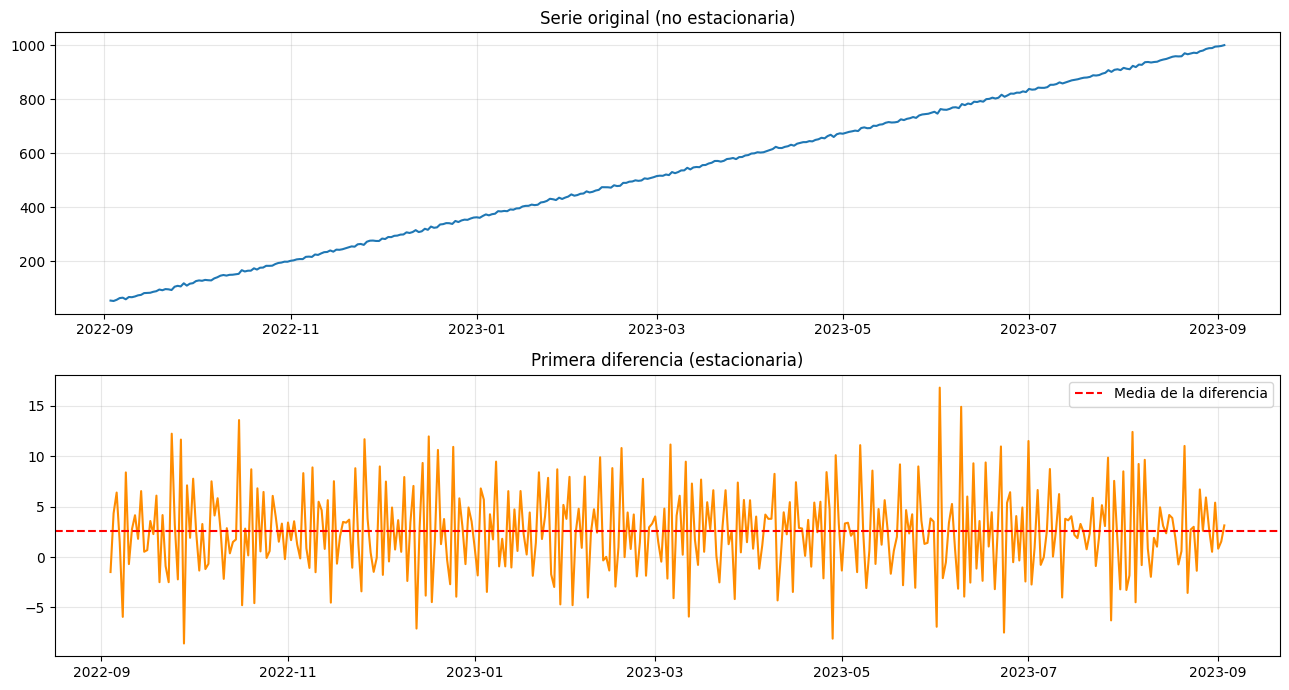

In [166]:
#Grafico de la serie diferenciada
fig, axis = plt.subplots(2, 1, figsize = (13, 7))

axis[0].plot(sales_series.index, sales_series.values)
axis[0].set_title("Serie original (no estacionaria)")
axis[0].grid(alpha = 0.3)

axis[1].plot(sales_series.index, sales_series.diff().values, color = "darkorange")
axis[1].axhline(sales_series.diff().mean(), color = "red", linestyle = "--",
                label = "Media de la diferencia")
axis[1].set_title("Primera diferencia (estacionaria)")
axis[1].legend()
axis[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

### Existe variabilidad o presencia de ruido?

In [167]:
#Cuantificacion del ruido
print("Incremento diario medio:", round(daily_change.mean(), 3))
print("Desviacion del incremento diario:", round(daily_change.std(), 3))
print("Ruido relativo (desviacion / media):", round(daily_change.std() / daily_change.mean(), 3))
print("")
print("Mayor subida en un dia:", round(daily_change.max(), 2))
print("Mayor bajada en un dia:", round(daily_change.min(), 2))

Incremento diario medio: 2.59
Desviacion del incremento diario: 4.259
Ruido relativo (desviacion / media): 1.645

Mayor subida en un dia: 16.79
Mayor bajada en un dia: -8.57


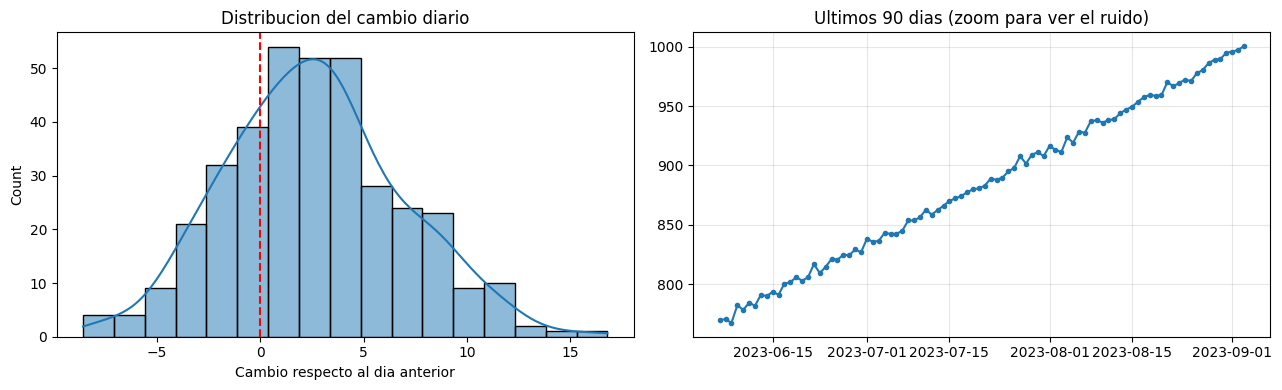

In [168]:
#Distribucion de los cambios diarios
fig, axis = plt.subplots(1, 2, figsize = (13, 4))

sns.histplot(ax = axis[0], x = daily_change.dropna(), kde = True)
axis[0].axvline(0, color = "red", linestyle = "--")
axis[0].set_title("Distribucion del cambio diario")
axis[0].set_xlabel("Cambio respecto al dia anterior")

axis[1].plot(sales_series.index[-90:], sales_series.values[-90:], marker = "o", markersize = 3)
axis[1].set_title("Ultimos 90 dias (zoom para ver el ruido)")
axis[1].grid(alpha = 0.3)

plt.tight_layout()
plt.show()

**Hay ruido considerable a escala diaria.** El incremento medio es de **2,59 unidades**
al dia pero la desviacion es de **4,26**, es decir, el ruido es **1,65 veces mayor que la
senal diaria**.

## ARIMA

### Train y Test

In [169]:
#Division cronologica 80/20
split_point = int(len(sales_series) * 0.8)

train_series = sales_series[:split_point]
test_series = sales_series[split_point:]

print("Train:", len(train_series), "observaciones -",
      train_series.index.min().date(), "a", train_series.index.max().date())
print("Test: ", len(test_series), "observaciones -",
      test_series.index.min().date(), "a", test_series.index.max().date())

Train: 292 observaciones - 2022-09-03 a 2023-06-21
Test:  74 observaciones - 2023-06-22 a 2023-09-03


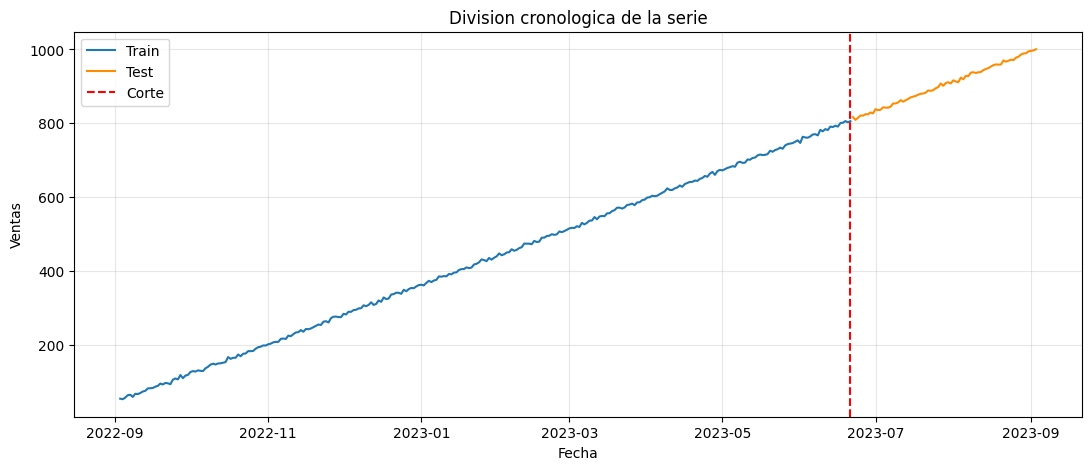

In [170]:
#Visualizacion de la division
plt.figure(figsize = (13, 5))
plt.plot(train_series.index, train_series.values, label = "Train")
plt.plot(test_series.index, test_series.values, label = "Test", color = "darkorange")
plt.axvline(train_series.index[-1], color = "red", linestyle = "--", label = "Corte")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Division cronologica de la serie")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

### Graficos de autocorrelacion

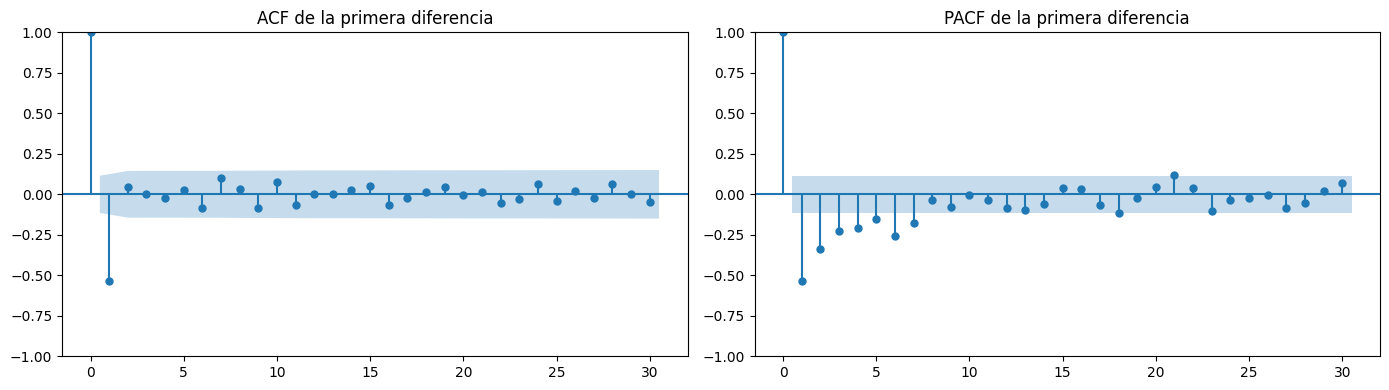

In [171]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axis = plt.subplots(1, 2, figsize = (14, 4))

plot_acf(train_series.diff().dropna(), lags = 30, ax = axis[0])
axis[0].set_title("ACF de la primera diferencia")

plot_pacf(train_series.diff().dropna(), lags = 30, ax = axis[1])
axis[1].set_title("PACF de la primera diferencia")

plt.tight_layout()
plt.show()

### Busqueda de la mejor parametrizacion

- **p** (AR): cuantos valores pasados usa el modelo
- **d** (I): cuantas veces hay que diferenciar para que la serie sea estacionaria
- **q** (MA): cuantos errores de prediccion pasados usa el modelo

In [172]:
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

search_rows = []

for p in range(0, 4):
    for d in range(0, 3):
        for q in range(0, 4):
            try:
                temporary_model = ARIMA(train_series, order = (p, d, q)).fit()
                search_rows.append([p, d, q, temporary_model.aic])
            except:
                pass

search_table = pd.DataFrame(search_rows, columns = ["p", "d", "q", "AIC"])
search_table = search_table.sort_values("AIC").reset_index(drop = True)

print("Combinaciones probadas:", len(search_table))
search_table.head(10).round(2)

Combinaciones probadas: 48


,p,d,q,AIC
0,0,2,3,1482.36
1,1,2,2,1482.40
2,0,2,2,1483.85
3,2,2,2,1484.37
4,3,2,2,1486.25
5,1,2,3,1486.39
6,2,2,3,1486.40
7,3,2,3,1488.36
8,1,1,3,1489.53
9,2,1,2,1490.00


**La mejor combinacion es `(0, 2, 3)`** con un AIC de 1482,36.

In [173]:
#Entrenamiento del modelo definitivo
best_p = search_table.loc[0, "p"]
best_d = search_table.loc[0, "d"]
best_q = search_table.loc[0, "q"]

arima_model = ARIMA(train_series, order = (best_p, best_d, best_q)).fit()

print("Orden elegido:", (best_p, best_d, best_q))
print("")
print(arima_model.summary())

Orden elegido: (np.int64(0), np.int64(2), np.int64(3))

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                  292
Model:                 ARIMA(0, 2, 3)   Log Likelihood                -737.180
Date:                Wed, 16 Sep 2026   AIC                           1482.360
Time:                        20:16:02   BIC                           1497.039
Sample:                    09-03-2022   HQIC                          1488.241
                         - 06-21-2023                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -2.0084      0.563     -3.569      0.000      -3.111      -0.905
ma.L2          1.0912      0.580      1.882      0.060      -0.045       2.

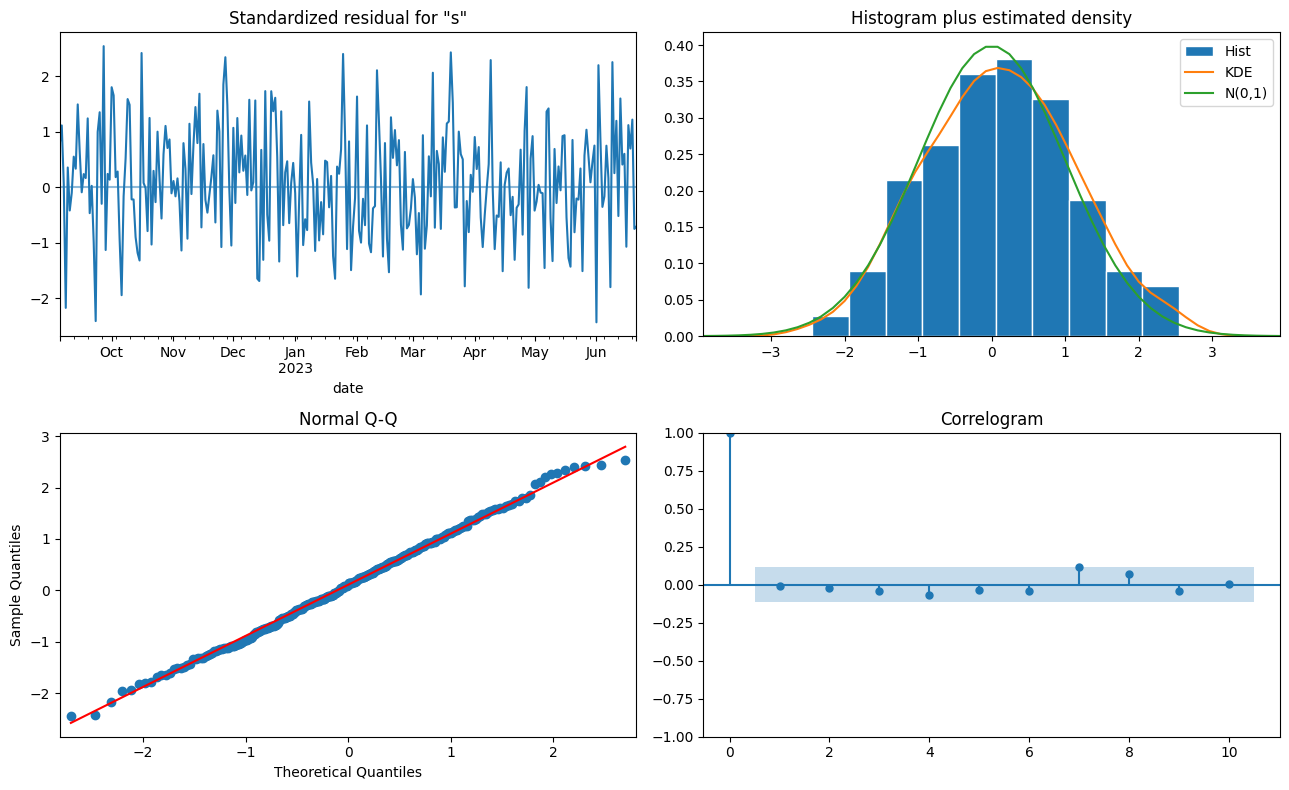

In [174]:
#Diagnostico de los residuos del modelo
arima_model.plot_diagnostics(figsize = (13, 8))
plt.tight_layout()
plt.show()

## Predice con el conjunto de test

In [175]:
#Prediccion de los 74 dias del conjunto de test
forecast = arima_model.forecast(steps = len(test_series))

#Intervalo de confianza de la prediccion
forecast_object = arima_model.get_forecast(steps = len(test_series))
confidence_interval = forecast_object.conf_int()

comparison = pd.DataFrame()
comparison["real"] = test_series
comparison["prediccion"] = forecast.values
comparison["error"] = (test_series.values - forecast.values)

comparison.head(10).round(3)

,real,prediccion,error
date,,,
2023-06-22,816.912,810.514,6.398
2023-06-23,809.423,812.935,-3.513
2023-06-24,814.798,815.533,-0.735
2023-06-25,821.219,818.131,3.088
2023-06-26,820.704,820.729,-0.025
2023-06-27,824.763,823.326,1.436
2023-06-28,824.418,825.924,-1.506
2023-06-29,829.329,828.522,0.807
2023-06-30,826.902,831.120,-4.217


In [176]:
#Metricas de rendimiento
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rmse = np.sqrt(mean_squared_error(test_series, forecast))
mae = mean_absolute_error(test_series, forecast)
r2 = r2_score(test_series, forecast)
mape = np.mean(np.abs((test_series.values - forecast.values) / test_series.values)) * 100

print("RMSE:", round(rmse, 4))
print("MAE: ", round(mae, 4))
print("R2:  ", round(r2, 4))
print("MAPE:", round(mape, 3), "%")

RMSE: 2.8247
MAE:  2.2721
R2:   0.9974
MAPE: 0.253 %


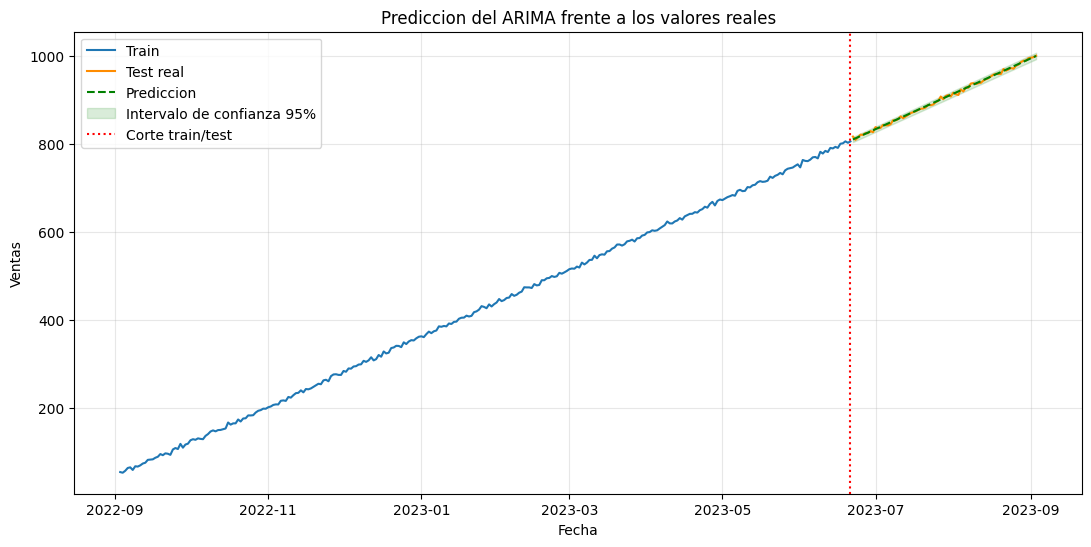

In [177]:
#Grafico de la prediccion frente a los valores reales
plt.figure(figsize = (13, 6))

plt.plot(train_series.index, train_series.values, label = "Train")
plt.plot(test_series.index, test_series.values, label = "Test real", color = "darkorange")
plt.plot(test_series.index, forecast.values, label = "Prediccion", color = "green",
         linestyle = "--")
plt.fill_between(test_series.index,
                 confidence_interval.iloc[:, 0],
                 confidence_interval.iloc[:, 1],
                 color = "green", alpha = 0.15, label = "Intervalo de confianza 95%")

plt.axvline(train_series.index[-1], color = "red", linestyle = ":", label = "Corte train/test")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Prediccion del ARIMA frente a los valores reales")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

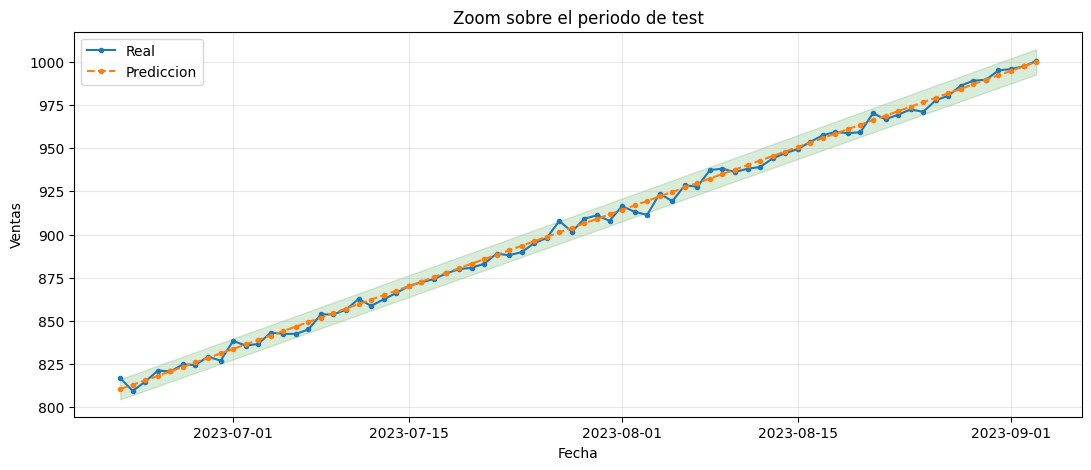

In [178]:
#Zoom sobre el periodo de test
plt.figure(figsize = (13, 5))

plt.plot(test_series.index, test_series.values, label = "Real", marker = "o", markersize = 3)
plt.plot(test_series.index, forecast.values, label = "Prediccion", linestyle = "--", marker = "o",
         markersize = 3)
plt.fill_between(test_series.index,
                 confidence_interval.iloc[:, 0],
                 confidence_interval.iloc[:, 1],
                 color = "green", alpha = 0.15)

plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Zoom sobre el periodo de test")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

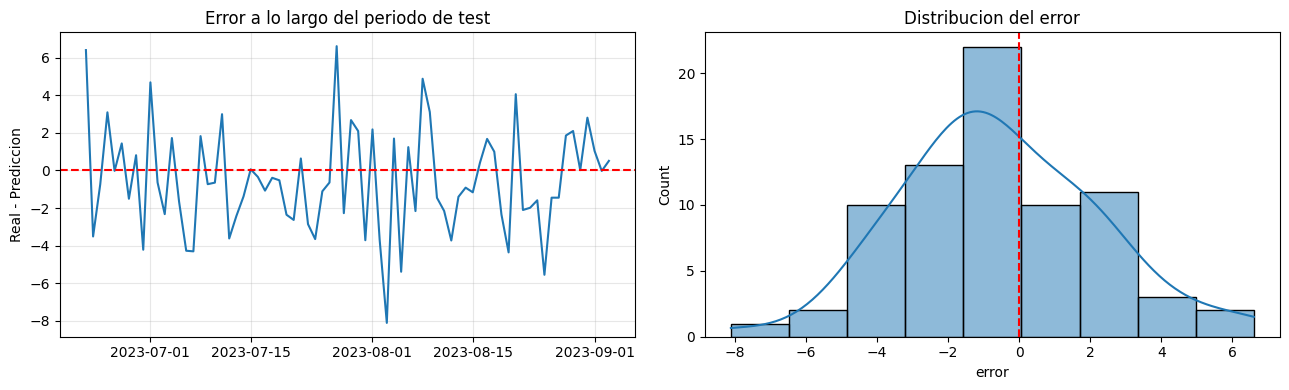

Error medio: -0.5548
Error maximo: 8.107


In [179]:
#Distribucion de los errores de prediccion
fig, axis = plt.subplots(1, 2, figsize = (13, 4))

axis[0].plot(test_series.index, comparison["error"].values)
axis[0].axhline(0, color = "red", linestyle = "--")
axis[0].set_title("Error a lo largo del periodo de test")
axis[0].set_ylabel("Real - Prediccion")
axis[0].grid(alpha = 0.3)

sns.histplot(ax = axis[1], x = comparison["error"], kde = True)
axis[1].axvline(0, color = "red", linestyle = "--")
axis[1].set_title("Distribucion del error")

plt.tight_layout()
plt.show()

print("Error medio:", round(comparison["error"].mean(), 4))
print("Error maximo:", round(comparison["error"].abs().max(), 4))

la serie tiene una tendencia lineal muy limpia, sin estacionalidad
ni cambios de regimen. Es un escenario casi ideal para ARIMA. Con una serie real de ventas
(con campanas, festivos y estacionalidad) los numeros serian bastante peores.

## Guardando el modelo

In [180]:
import pickle

os.makedirs("./modelos_ml", exist_ok = True)

with open("./modelos_ml/arima_model.pkl", "wb") as file:
    pickle.dump(arima_model, file)

print("Modelo guardado en ./modelos_ml/arima_model.pkl")

Modelo guardado en ./modelos_ml/arima_model.pkl


In [181]:
#Guardado de la serie procesada y de la comparacion
df.to_csv("/Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-Time-Series/data/processed/sales_timeseries.csv")
comparison.to_csv("/Users/jonat/OneDrive/Desktop/4geeks/Machine-Learning-Time-Series/data/processed/forecast_vs_real.csv")

print("Datos guardados en ./data/processed/")

Datos guardados en ./data/processed/


## Aplicacion al problema de negocio

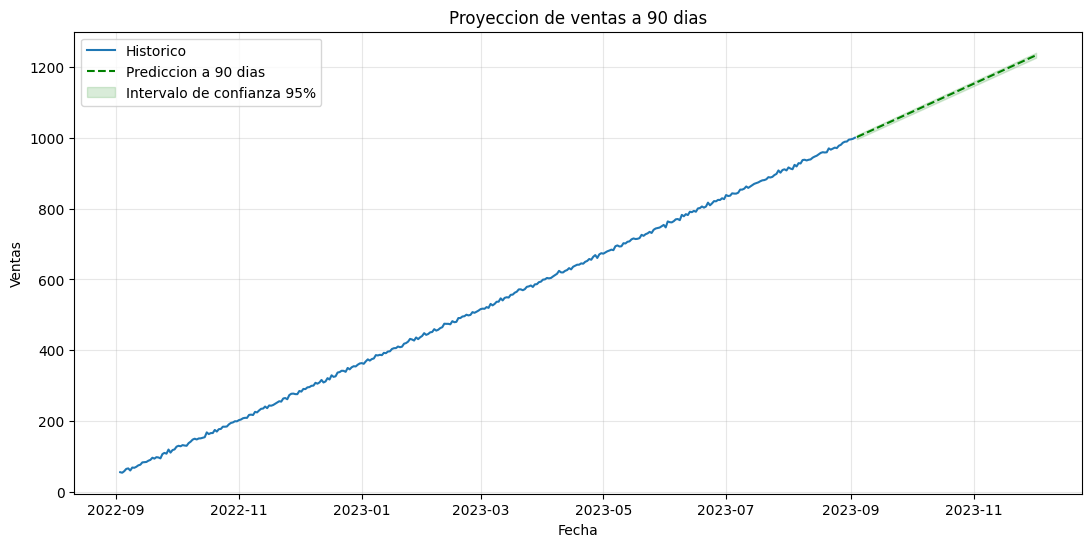

Ventas del ultimo dia observado: 1000.48
Prediccion a 30 dias: 1077.62
Prediccion a 60 dias: 1155.54
Prediccion a 90 dias: 1233.47


In [182]:
#Modelo reentrenado con la serie completa para proyectar a futuro
final_model = ARIMA(sales_series, order = (best_p, best_d, best_q)).fit()

future_days = 90
future_forecast = final_model.get_forecast(steps = future_days)
future_values = future_forecast.predicted_mean
future_interval = future_forecast.conf_int()

plt.figure(figsize = (13, 6))
plt.plot(sales_series.index, sales_series.values, label = "Historico")
plt.plot(future_values.index, future_values.values, label = "Prediccion a 90 dias",
         color = "green", linestyle = "--")
plt.fill_between(future_values.index,
                 future_interval.iloc[:, 0],
                 future_interval.iloc[:, 1],
                 color = "green", alpha = 0.15, label = "Intervalo de confianza 95%")
plt.xlabel("Fecha")
plt.ylabel("Ventas")
plt.title("Proyeccion de ventas a 90 dias")
plt.legend()
plt.grid(alpha = 0.3)
plt.show()

print("Ventas del ultimo dia observado:", round(sales_series.iloc[-1], 2))
print("Prediccion a 30 dias:", round(future_values.iloc[29], 2))
print("Prediccion a 60 dias:", round(future_values.iloc[59], 2))
print("Prediccion a 90 dias:", round(future_values.iloc[89], 2))